# Custom Envelope Functions

This notebook shows how to implement a **Gaussian spot envelope** by subclassing
`EnvelopeFunction`, and how to progressively add closed-form analytic expressions
for `Gamma_hat(omega)` and `R_Gamma(tlag)`.

`check_functions()` is used at each step to verify the analytic implementation
against the FFT-based numerical baseline and to measure the accuracy and runtime
speedup of each approach.

**Sections**
1. Analytic equations for the Gaussian envelope
2. Minimal implementation — `Gamma(t)` only
3. Add analytic `Gamma_hat(omega)` — accuracy and timing
4. Add analytic `R_Gamma(tlag)` — accuracy and timing
5. Build a `SpotEvolutionModel` with the finished envelope

In [1]:
import sys
sys.path.append("../..")

import time
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from src_jax import (
    EnvelopeFunction,
    VisibilityFunction,
    SpotEvolutionModel,
    AnalyticKernel,
)

label_fs = 18
np.random.seed(42)

---
## 1. Analytic equations for the Gaussian envelope

A Gaussian spot profile is centred at $t = 0$ with standard deviation $\sigma$:

$$\Gamma(t) = \exp\!\left(-\frac{t^2}{2\sigma^2}\right)$$

The Fourier transform and autocorrelation both have closed forms.

### Fourier transform $\hat{\Gamma}(\omega)$

The Fourier transform of a Gaussian is a Gaussian:

$$\hat{\Gamma}(\omega)
  = \int_{-\infty}^{\infty} \Gamma(t)\, e^{-i\omega t}\, dt
  = \sigma\sqrt{2\pi}\; \exp\!\left(-\frac{\omega^2 \sigma^2}{2}\right)$$

### Autocorrelation $R_{\Gamma}(\tau)$

$$R_{\Gamma}(\tau)
  = \int_{-\infty}^{\infty} \Gamma(t)\,\Gamma(t+\tau)\, dt
  = \sigma\sqrt{\pi}\; \exp\!\left(-\frac{\tau^2}{4\sigma^2}\right)$$

Both expressions are real and symmetric, and the integrals converge for all $\sigma > 0$.

---
## 2. Minimal implementation — `Gamma(t)` only

The only **required** methods are `tau_spot` (a property returning the
characteristic timescale) and `Gamma(t)`.  Everything else — `Gamma_hat`,
`R_Gamma`, `kernel_support`, `param_dict` — has working defaults in the base
class that fall back to FFT-based numerical approximations.

`check_functions()` detects which functions have been overridden and reports
`no analytic overrides found` when only the numerical fallbacks are in use.

In [2]:
class GaussianEnvelopeNumerical(EnvelopeFunction):
    """Gaussian spot envelope — Gamma(t) only, no analytic overrides."""

    def __init__(self, sigma: float):
        self._sigma = float(sigma)

    @property
    def tau_spot(self) -> float:
        return self._sigma

    @property
    def param_dict(self) -> dict:
        return {"sigma": self._sigma}

    def Gamma(self, t):
        return jnp.exp(-0.5 * (t / self._sigma) ** 2)

In [3]:
env_num = GaussianEnvelopeNumerical(sigma=5.0)
print("param_dict     :", env_num.param_dict)
print("tau_spot       :", env_num.tau_spot)
print("kernel_support :", env_num.kernel_support(), "days")
print()
errors = env_num.check_functions()
print("errors:", errors)

param_dict     : {'sigma': 5.0}
tau_spot       : 5.0
kernel_support : 30.0 days

GaussianEnvelopeNumerical: no analytic overrides found for Gamma_hat or R_Gamma — nothing to check.
errors: {}


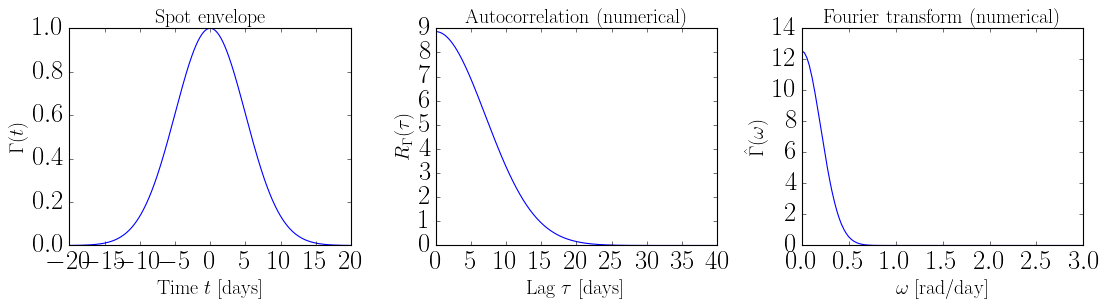

In [4]:
t   = np.linspace(-20, 20, 500)
lag = np.linspace(0, 40, 500)
om  = np.linspace(0, 3, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(t, env_num.Gamma(jnp.array(t)))
axes[0].set_xlabel(r"Time $t$ [days]", fontsize=label_fs)
axes[0].set_ylabel(r"$\Gamma(t)$", fontsize=label_fs)
axes[0].set_title("Spot envelope", fontsize=label_fs)

axes[1].plot(lag, env_num.R_Gamma(jnp.array(lag)))
axes[1].set_xlabel(r"Lag $\tau$ [days]", fontsize=label_fs)
axes[1].set_ylabel(r"$R_\Gamma(\tau)$", fontsize=label_fs)
axes[1].set_title("Autocorrelation (numerical)", fontsize=label_fs)

axes[2].plot(om, env_num.Gamma_hat(jnp.array(om)))
axes[2].set_xlabel(r"$\omega$ [rad/day]", fontsize=label_fs)
axes[2].set_ylabel(r"$\hat{\Gamma}(\omega)$", fontsize=label_fs)
axes[2].set_title("Fourier transform (numerical)", fontsize=label_fs)

fig.tight_layout()
plt.show()

---
## 3. Add analytic `Gamma_hat(omega)`

Override `Gamma_hat` with the closed-form Gaussian Fourier transform.
`check_functions()` will now detect the override and compare it to the
FFT baseline, reporting the RMSE and max absolute error.

In [5]:
class GaussianEnvelopeAnalyticFT(EnvelopeFunction):
    """Gaussian envelope with analytic Gamma_hat(omega)."""

    def __init__(self, sigma: float):
        self._sigma = float(sigma)

    @property
    def tau_spot(self) -> float:
        return self._sigma

    @property
    def param_dict(self) -> dict:
        return {"sigma": self._sigma}

    def Gamma(self, t):
        return jnp.exp(-0.5 * (t / self._sigma) ** 2)

    def Gamma_hat(self, omega):
        # FT of Gaussian: sigma * sqrt(2*pi) * exp(-omega^2 * sigma^2 / 2)
        return self._sigma * jnp.sqrt(2 * jnp.pi) * jnp.exp(-0.5 * (omega * self._sigma) ** 2)

Check that our analytic equation is correct by comparing it to the numerical solution:

Gamma_hat  RMSE = 2.27e-04,  max err = 1.92e-03
  analytic  time = 0.690 ms
  numerical time = 0.065 ms


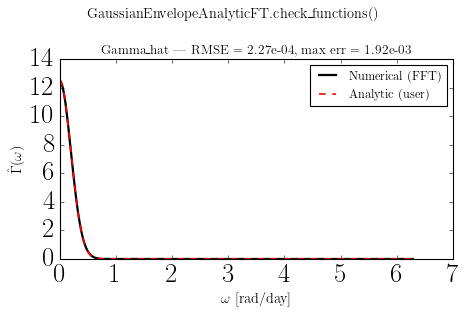

In [7]:
env_ft = GaussianEnvelopeAnalyticFT(sigma=5.0)
errors_ft = env_ft.check_functions()

For this evaluation the analytic time is slower than the numerical time because of the JAX JIT compilation on the first run. As a better comparison, we can compare the timing after JIT warmup.

### Timing: analytic vs numerical `Gamma_hat`

Compare evaluation time for 1 000 calls on a 500-point omega grid.

In [8]:
omega_arr = jnp.linspace(0, 3.0, 500)
n_calls   = 1000

# Ensure both numerical grids are pre-built before timing
env_num._ensure_numerical_grids()
env_ft._ensure_numerical_grids()

# Warm up JAX JIT
_ = env_num.Gamma_hat(omega_arr)
_ = env_ft.Gamma_hat(omega_arr)

t0 = time.perf_counter()
for _ in range(n_calls):
    env_num.Gamma_hat(omega_arr)
t_numerical = (time.perf_counter() - t0) / n_calls * 1e3

t0 = time.perf_counter()
for _ in range(n_calls):
    env_ft.Gamma_hat(omega_arr)
t_analytic = (time.perf_counter() - t0) / n_calls * 1e3

print(f"Gamma_hat  numerical : {t_numerical:.3f} ms/call")
print(f"Gamma_hat  analytic  : {t_analytic:.3f} ms/call")
print(f"Speedup              : {t_numerical / t_analytic:.1f}x")

Gamma_hat  numerical : 0.193 ms/call
Gamma_hat  analytic  : 0.129 ms/call
Speedup              : 1.5x


If you were to increase n_pts to something large (e.g. 100k+), the analytic version would likely pull ahead because the `np.interp` of the numerical solution cost grows linearly while the JIT-compiled XLA kernel stays roughly flat. 

---
## 4. Add analytic `R_Gamma(tlag)`

Override `R_Gamma` with the closed-form Gaussian autocorrelation.
`check_functions()` now checks both overrides simultaneously.

In [9]:
class GaussianEnvelope(EnvelopeFunction):
    """
    Gaussian spot envelope with fully analytic Gamma_hat and R_Gamma.

    Parameters
    ----------
    sigma : float
        Standard deviation of the Gaussian profile [days].
    """

    def __init__(self, sigma: float):
        self._sigma = float(sigma)

    @property
    def tau_spot(self) -> float:
        return self._sigma

    @property
    def param_dict(self) -> dict:
        return {"sigma": self._sigma}

    def Gamma(self, t):
        return jnp.exp(-0.5 * (t / self._sigma) ** 2)

    def Gamma_hat(self, omega):
        # FT of Gaussian: sigma * sqrt(2*pi) * exp(-omega^2 * sigma^2 / 2)
        return self._sigma * jnp.sqrt(2 * jnp.pi) * jnp.exp(-0.5 * (omega * self._sigma) ** 2)

    def R_Gamma(self, lag):
        # Autocorrelation of Gaussian: sigma * sqrt(pi) * exp(-lag^2 / (4*sigma^2))
        return self._sigma * jnp.sqrt(jnp.pi) * jnp.exp(-0.25 * (lag / self._sigma) ** 2)

Gamma_hat  RMSE = 2.27e-04,  max err = 1.92e-03
  analytic  time = 0.747 ms
  numerical time = 0.049 ms
R_Gamma  RMSE = 6.20e-07,  max err = 2.11e-06
  analytic  time = 0.755 ms
  numerical time = 0.048 ms


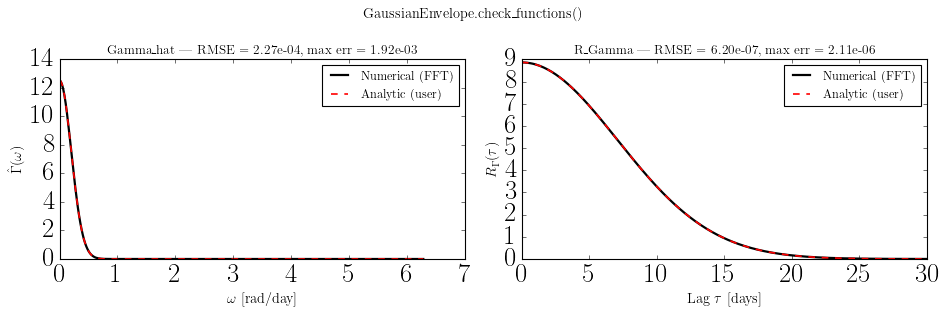

In [11]:
env = GaussianEnvelope(sigma=5.0)
errors = env.check_functions()

### Timing: analytic vs numerical for both functions

Compare `R_Gamma` and `Gamma_hat` evaluation time across 1 000 calls on a
500-point grid.

In [12]:
lag_arr   = jnp.linspace(0, 6 * env.tau_spot, 500)
omega_arr = jnp.linspace(0, 3.0, 500)
n_calls   = 1000

# Pre-build numerical grids and warm up
env_num._ensure_numerical_grids()
env._ensure_numerical_grids()
_ = env_num.R_Gamma(lag_arr);   _ = env.R_Gamma(lag_arr)
_ = env_num.Gamma_hat(omega_arr); _ = env.Gamma_hat(omega_arr)

results = {}
for label, obj, arr, fname in [
    ("numerical", env_num, lag_arr,   "R_Gamma"),
    ("analytic",  env,     lag_arr,   "R_Gamma"),
    ("numerical", env_num, omega_arr, "Gamma_hat"),
    ("analytic",  env,     omega_arr, "Gamma_hat"),
]:
    func = getattr(obj, fname)
    t0 = time.perf_counter()
    for _ in range(n_calls):
        func(arr)
    results[(fname, label)] = (time.perf_counter() - t0) / n_calls * 1e3

print(f"{'Function':12s}  {'Method':10s}  {'ms/call':>9s}  {'speedup':>8s}")
print("-" * 48)
for fname in ("R_Gamma", "Gamma_hat"):
    t_num = results[(fname, "numerical")]
    t_an  = results[(fname, "analytic")]
    print(f"{fname:12s}  {'numerical':10s}  {t_num:9.3f}")
    print(f"{fname:12s}  {'analytic':10s}  {t_an:9.3f}  {t_num/t_an:7.1f}x")

Function      Method        ms/call   speedup
------------------------------------------------
R_Gamma       numerical       0.184
R_Gamma       analytic        0.127      1.4x
Gamma_hat     numerical       0.161
Gamma_hat     analytic        0.130      1.2x


---
## 5. Build a `SpotEvolutionModel` with the Gaussian envelope

The finished `GaussianEnvelope` plugs directly into `SpotEvolutionModel` and
`AnalyticKernel` just like any built-in envelope.

In [13]:
visibility = VisibilityFunction(
    peq=10.0,
    kappa=0.3,
    inc=np.pi / 3,
)

model = SpotEvolutionModel(
    envelope=GaussianEnvelope(sigma=5.0),
    visibility=visibility,
    sigma_k=0.01,
)

print("param_keys:", model.param_keys)
print(model)

param_keys: ('peq', 'kappa', 'inc', 'sigma', 'sigma_k')
SpotEvolutionModel(
  envelope=GaussianEnvelope({'sigma': 5.0}),
  visibility=VisibilityFunction(peq=10.0, kappa=0.3, inc=1.047),
  sigma_k=0.01
)


JAX kernel compiled in 0.27s
JAX kernel recompute in 0.23s


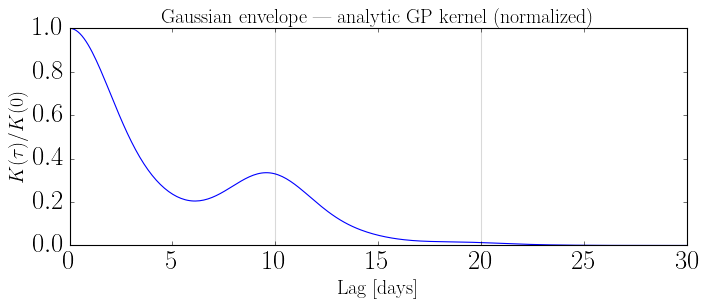

In [16]:
ak = AnalyticKernel(model).build_jax()

lag = np.linspace(0, 3 * model.peq, 300)
K   = ak.kernel(lag)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lag, K / K[0])
for n in range(int(lag[-1] / model.peq) + 1):
    ax.axvline(n * model.peq, color="k", alpha=0.15, lw=1)
ax.set_xlabel("Lag [days]", fontsize=label_fs)
ax.set_ylabel(r"$K(\tau) / K(0)$", fontsize=label_fs)
ax.set_title("Gaussian envelope — analytic GP kernel (normalized)", fontsize=label_fs)
fig.tight_layout()
plt.show()